# Análise — Custos Fevereiro e Erosão MACO Março
**Contexto:** Fevereiro — rodo emergencial SP→NENO | Março — cabotagem +10% demanda  
**Foco:** Custos isolados de fevereiro + erosão de MACO em março sem comparação direta  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Paleta ────────────────────────────────────────────────────────────────────
NAVY    = '#1a237e'
AZUL    = '#2a4d69'
ANTES   = '#58a6ff'   # fevereiro
DEPOIS  = '#f78166'   # março
VERDE   = '#2e7d32'
VERM    = '#c62828'
AMARELO = '#f9a825'
ROXO    = '#6a1b9a'
CINZA   = '#90a4ae'
CABO_C  = '#00838f'   # cor cabotagem
RODO_C  = '#e65100'   # cor rodoviário

plt.rcParams.update({
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#cccccc', 'axes.labelcolor': NAVY,
    'xtick.color': NAVY, 'ytick.color': NAVY,
    'text.color': NAVY, 'grid.color': '#e0e0e0',
    'grid.linestyle': '--', 'grid.alpha': 0.6,
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'legend.facecolor': '#f5f5f5', 'legend.edgecolor': '#cccccc',
    'legend.labelcolor': NAVY,
})

SKUS   = ['MALZBIER', 'GOOSE', 'COLORADO']
LABELS = {'MALZBIER': 'Malzbier Brahma', 'GOOSE': 'Goose Island', 'COLORADO': 'Colorado Lager'}
CORES  = {'MALZBIER': AZUL, 'GOOSE': ROXO, 'COLORADO': VERDE}
SEMS   = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']
SEMS_S = ['W0', 'W1', 'W2', 'W3']
print('✅ Setup OK')


✅ Setup OK


## 1. Leitura do Excel — Cenário Nova Demanda (Fevereiro)


In [3]:
XLS = 'Analise_LongNeck_WSNP - Sem repostas.xlsx'

df_nd = pd.read_excel(XLS, sheet_name='Cenário com Nova Demanda', header=None)
df_cd = pd.read_excel(XLS, sheet_name='Cenário Divulgado',        header=None)
df_ct = pd.read_excel(XLS, sheet_name='Custos de transferência',  header=None)

# ── Mapeamento de colunas (validado célula a célula) ──────────────────────────
_SC = {
    'W0': {'dem': 3,  'ei': 7,  'ef': 13},
    'W1': {'dem': 16,           'ef': 24},
    'W2': {'dem': 27,           'ef': 35},
    'W3': {'dem': 38,           'ef': 46},
}
_SEMS     = ['W0', 'W1', 'W2', 'W3']
_ALL_GEOS = ['Mapapi', 'NE Norte', 'NE Sul', 'NO Araguaia', 'NO Centro']
_CDR_GEO  = {'Mapapi': 'PB', 'NE Norte': 'PB', 'NE Sul': 'BA', 'NO Centro': 'PB'}

# Linha de início por SKU (TI = linha total, GS = linha GEO start)
TI = {'MALZBIER': 25, 'GOOSE': 17, 'COLORADO': 33}
GS = {'MALZBIER': 20, 'GOOSE': 12, 'COLORADO': 28}

BIAS    = 1.09
DOI_MIN = 12
MACO    = {'MALZBIER': 285, 'GOOSE': 350, 'COLORADO': 300}

# Custos cabo (R$/HL) — lidos do Excel
_CABO = {
    ('COLORADO','BA'): df_ct.iloc[3,4], ('COLORADO','PB'): df_ct.iloc[4,4],
    ('GOOSE',   'BA'): df_ct.iloc[5,4], ('GOOSE',   'PB'): df_ct.iloc[7,4],
    ('MALZBIER','BA'): df_ct.iloc[6,4], ('MALZBIER','PB'): df_ct.iloc[8,4],
}

# EF W3 fevereiro — resultado do planejamento de fevereiro
EF_W3_FEV = {'MALZBIER': 31383, 'GOOSE': 38709, 'COLORADO': 13213}

print(f'Excel carregado: {df_nd.shape[0]} linhas × {df_nd.shape[1]} colunas')
print('Custos cabotagem (R$/HL):')
for sku in SKUS:
    print(f'  {LABELS[sku]:20s} BA={_CABO[(sku,"BA")]:.2f}  PB={_CABO[(sku,"PB")]:.2f}')


Excel carregado: 49 linhas × 48 colunas
Custos cabotagem (R$/HL):
  Malzbier Brahma      BA=84.58  PB=95.33
  Goose Island         BA=82.40  PB=88.30
  Colorado Lager       BA=76.59  PB=82.08


## 2. Cálculo — Demanda e MACO Fevereiro × Março


In [4]:
# ── Demanda fevereiro (Excel) ─────────────────────────────────────────────────
dem_fev_nd = {sku: sum(df_nd.iloc[TI[sku], _SC[s]['dem']] for s in _SEMS) / BIAS for sku in SKUS}
dem_fev_cd = {sku: sum(df_cd.iloc[TI[sku], _SC[s]['dem']] for s in _SEMS) / BIAS for sku in SKUS}

# Demanda fev por semana (c/BIAS)
dem_fev_sem = {
    sku: [df_nd.iloc[TI[sku], _SC[s]['dem']] / BIAS for s in _SEMS]
    for sku in SKUS
}

# ── Demanda março: base fev ND × 1.10 ÷ 4 (distribuição uniforme) ────────────
dem_mar_sem = {sku: dem_fev_nd[sku] * 1.10 / 4 for sku in SKUS}  # por semana
dem_mar_tot = {sku: dem_mar_sem[sku] * 4       for sku in SKUS}  # total estimado

# ── Split BA/PB baseado em W0 fev ────────────────────────────────────────────
def prop_ba(sku):
    g = GS[sku]
    ba = sum(df_nd.iloc[g+j, _SC['W0']['dem']] for j,geo in enumerate(_ALL_GEOS)
             if geo in _CDR_GEO and _CDR_GEO[geo]=='BA')
    pb = sum(df_nd.iloc[g+j, _SC['W0']['dem']] for j,geo in enumerate(_ALL_GEOS)
             if geo in _CDR_GEO and _CDR_GEO[geo]=='PB')
    return ba / (ba + pb)

PBA = {sku: prop_ba(sku) for sku in SKUS}

# ── Balanço março W0 ──────────────────────────────────────────────────────────
res_mar = {}
for sku in SKUS:
    ei      = EF_W3_FEV[sku]
    dem     = dem_mar_sem[sku]
    ef_s    = ei - dem
    doi_s   = ef_s / dem * 6
    transf  = max(0., DOI_MIN * dem / 6 - ef_s)
    emb_ba  = transf * PBA[sku]
    emb_pb  = transf * (1 - PBA[sku])
    custo   = emb_ba * _CABO[(sku,'BA')] + emb_pb * _CABO[(sku,'PB')]
    ef_fin  = ef_s + transf
    doi_fin = ef_fin / dem * 6
    res_mar[sku] = {
        'ei': ei, 'dem': dem, 'ef_sem': ef_s, 'doi_sem': doi_s,
        'transf': transf, 'emb_ba': emb_ba, 'emb_pb': emb_pb,
        'custo': custo, 'ef_fin': ef_fin, 'doi_fin': doi_fin,
        'maco_bruto':  transf * MACO[sku],
        'maco_liq':    transf * MACO[sku] - custo,
        'maco_local':  (dem - transf) * MACO[sku],
        'custo_ba':    emb_ba * _CABO[(sku,'BA')],
        'custo_pb':    emb_pb * _CABO[(sku,'PB')],
        'cabo_ba':     _CABO[(sku,'BA')],
        'cabo_pb':     _CABO[(sku,'PB')],
        'cabo_medio':  _CABO[(sku,'BA')]*PBA[sku] + _CABO[(sku,'PB')]*(1-PBA[sku]),
        'maco_liq_hl': MACO[sku] - (_CABO[(sku,'BA')]*PBA[sku] + _CABO[(sku,'PB')]*(1-PBA[sku])),
        'erosao_pct':  custo / (transf * MACO[sku]) * 100 if transf > 0 else 0,
    }

# ── Fevereiro hardcoded (rodo emergencial) ────────────────────────────────────
RODO = {
    ('MALZBIER','BA'): 135.33, ('MALZBIER','PB'): 152.53,
    ('GOOSE',   'BA'): 131.83, ('GOOSE',   'PB'): 141.28,
    ('COLORADO','BA'): 122.55, ('COLORADO','PB'): 131.33,
}
res_fev = {
    'MALZBIER': {'transf': 15103, 'emb_ba': 3803,  'emb_pb': 12095, 'doi_fin': 12.0,
                 'custo': 3803*135.33 + 12095*152.53, 'dem_tot': dem_fev_nd['MALZBIER']},
    'GOOSE':    {'transf': 15030, 'emb_ba': 7348,  'emb_pb': 7682,  'doi_fin': 12.0,
                 'custo': 7348*131.83 + 7682*141.28,  'dem_tot': dem_fev_nd['GOOSE']},
    'COLORADO': {'transf': 0,     'emb_ba': 0,     'emb_pb': 0,     'doi_fin': 18.5,
                 'custo': 0,                           'dem_tot': dem_fev_nd['COLORADO']},
}
for sku in SKUS:
    r = res_fev[sku]
    r['maco_bruto'] = r['transf'] * MACO[sku]
    r['maco_liq']   = r['maco_bruto'] - r['custo']
    r['custo_hl']   = r['custo'] / r['transf'] if r['transf'] > 0 else 0
    r['erosao_pct'] = r['custo'] / r['maco_bruto'] * 100 if r['maco_bruto'] > 0 else 0
    r['custo_ba']   = r['emb_ba'] * RODO.get((sku,'BA'), 0)
    r['custo_pb']   = r['emb_pb'] * RODO.get((sku,'PB'), 0)

print('Resultados calculados:')
for sku in SKUS:
    r = res_mar[sku]
    print(f'  {LABELS[sku]:20s} transf={r["transf"]:,.0f} HL | custo=R${r["custo"]:,.0f} | MACO_liq=R${r["maco_liq"]:,.0f} | DOI={r["doi_fin"]:.1f}d')


Resultados calculados:
  Malzbier Brahma      transf=6,926 HL | custo=R$642,431 | MACO_liq=R$1,331,464 | DOI=12.0d
  Goose Island         transf=2,973 HL | custo=R$258,702 | MACO_liq=R$781,897 | DOI=12.0d
  Colorado Lager       transf=4,487 HL | custo=R$363,367 | MACO_liq=R$982,709 | DOI=12.0d


## 3. Gráfico 1 — Custos de Frete Fevereiro Isolados


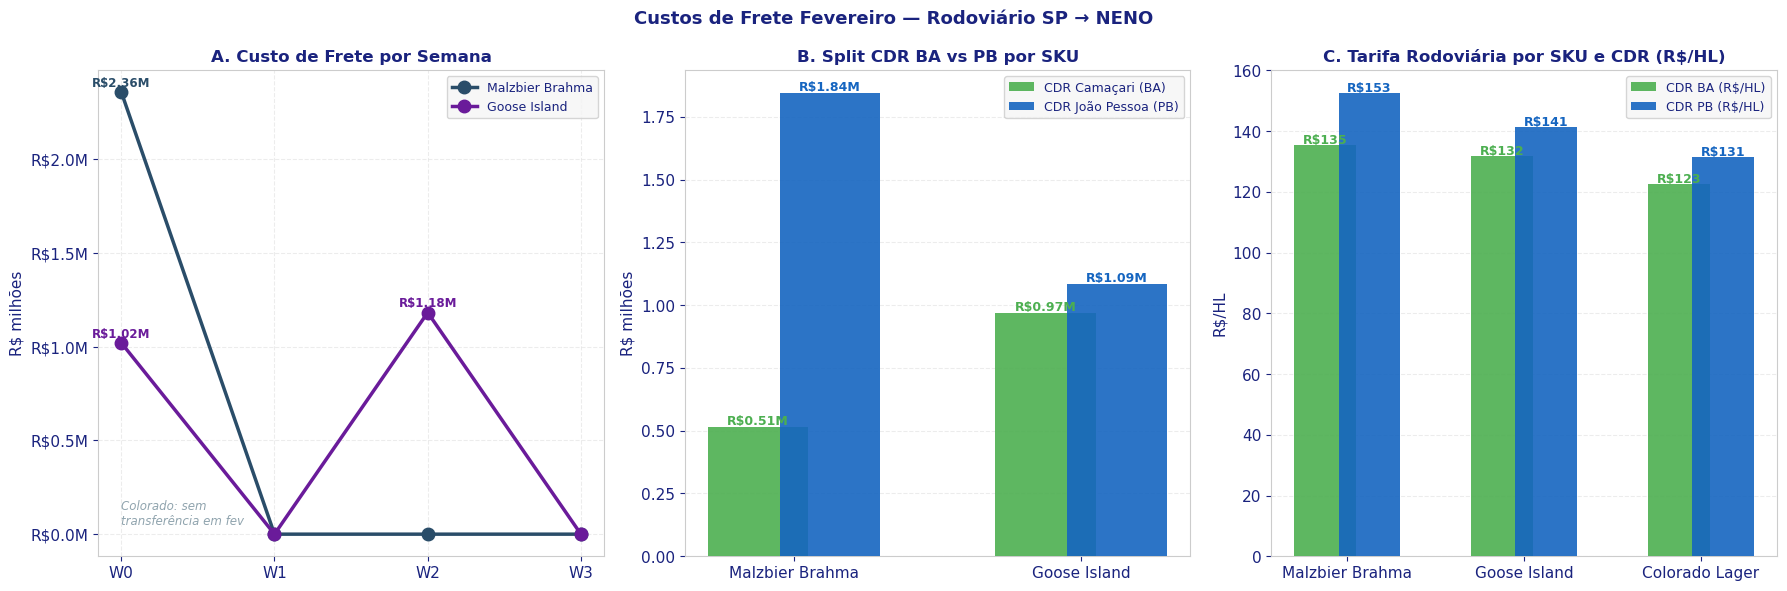

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Custos de Frete Fevereiro — Rodoviário SP → NENO', fontsize=13,
             fontweight='bold', color=NAVY)

# Dados fev isolados
fev_custo_sem = {
    'MALZBIER': [res_fev['MALZBIER']['custo'], 0, 0, 0],
    'GOOSE':    [1597*131.83+5737*141.28, 0, 1751*131.83+6736*141.28, 0],
    'COLORADO': [0, 0, 0, 0],
}
fev_custo_cdr = {
    sku: {'BA': res_fev[sku]['emb_ba']*RODO.get((sku,'BA'),0),
          'PB': res_fev[sku]['emb_pb']*RODO.get((sku,'PB'),0)}
    for sku in SKUS
}

xp = np.arange(4); w = 0.25

# ── A: Custo por semana (linha temporal) ──────────────────────────────────────
ax = axes[0]
for sku in ['MALZBIER','GOOSE']:
    vals = [v/1e6 for v in fev_custo_sem[sku]]
    ax.plot(xp, vals, 'o-', color=CORES[sku], lw=2.5, ms=9,
            label=LABELS[sku], zorder=5)
    for i,v in enumerate(vals):
        if v>0:
            ax.text(i, v+0.03, f'R${v:.2f}M', ha='center', fontsize=8.5,
                    fontweight='bold', color=CORES[sku])
ax.set_xticks(xp); ax.set_xticklabels(SEMS_S)
ax.set_ylabel('R$ milhões')
ax.set_title('A. Custo de Frete por Semana')
ax.legend(fontsize=9); ax.grid(zorder=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'R${v:.1f}M'))
ax.annotate('Colorado: sem\ntransferência em fev', xy=(0, 0.05),
            fontsize=8.5, color=CINZA, style='italic')

# ── B: Split BA vs PB por SKU ──────────────────────────────────────────────────
ax2 = axes[1]
x2 = np.arange(2)  # só Malzbier e Goose
skus_transf = ['MALZBIER','GOOSE']
ba_vals = [fev_custo_cdr[s]['BA']/1e6 for s in skus_transf]
pb_vals = [fev_custo_cdr[s]['PB']/1e6 for s in skus_transf]
bars_ba = ax2.bar(x2 - w/2, ba_vals, w*1.4, color='#4caf50', alpha=0.9,
                  label='CDR Camaçari (BA)', zorder=3)
bars_pb = ax2.bar(x2 + w/2, pb_vals, w*1.4, color='#1565c0', alpha=0.9,
                  label='CDR João Pessoa (PB)', zorder=3)
for b,v in zip(bars_ba, ba_vals):
    ax2.text(b.get_x()+b.get_width()/2, v+0.01, f'R${v:.2f}M',
             ha='center', fontsize=9, fontweight='bold', color='#4caf50')
for b,v in zip(bars_pb, pb_vals):
    ax2.text(b.get_x()+b.get_width()/2, v+0.01, f'R${v:.2f}M',
             ha='center', fontsize=9, fontweight='bold', color='#1565c0')
ax2.set_xticks(x2); ax2.set_xticklabels([LABELS[s] for s in skus_transf])
ax2.set_ylabel('R$ milhões')
ax2.set_title('B. Split CDR BA vs PB por SKU')
ax2.legend(fontsize=9); ax2.grid(axis='y', zorder=0)

# ── C: Custo unitário rodo por SKU e CDR ──────────────────────────────────────
ax3 = axes[2]
x3 = np.arange(3)
rodo_ba_vals = [RODO[(s,'BA')] for s in SKUS]
rodo_pb_vals = [RODO[(s,'PB')] for s in SKUS]
bars_rba = ax3.bar(x3 - w/2, rodo_ba_vals, w*1.4, color='#4caf50', alpha=0.9,
                   label='CDR BA (R$/HL)', zorder=3)
bars_rpb = ax3.bar(x3 + w/2, rodo_pb_vals, w*1.4, color='#1565c0', alpha=0.9,
                   label='CDR PB (R$/HL)', zorder=3)
for b,v in zip(bars_rba, rodo_ba_vals):
    ax3.text(b.get_x()+b.get_width()/2, v+0.5, f'R${v:.0f}',
             ha='center', fontsize=9, fontweight='bold', color='#4caf50')
for b,v in zip(bars_rpb, rodo_pb_vals):
    ax3.text(b.get_x()+b.get_width()/2, v+0.5, f'R${v:.0f}',
             ha='center', fontsize=9, fontweight='bold', color='#1565c0')
ax3.set_xticks(x3); ax3.set_xticklabels([LABELS[s] for s in SKUS])
ax3.set_ylabel('R$/HL')
ax3.set_title('C. Tarifa Rodoviária por SKU e CDR (R$/HL)')
ax3.legend(fontsize=9); ax3.grid(axis='y', zorder=0)

plt.tight_layout()
plt.savefig('g_mar_1_custos_fev.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()


## 4. Gráfico 2 — Waterfall MACO Fevereiro Isolado por SKU


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Waterfall MACO Fevereiro — Bruto → Frete → Líquido por SKU', fontsize=13,
             fontweight='bold', color=NAVY)

for ax, sku in zip(axes, SKUS):
    r    = res_fev[sku]
    cats = ['MACO\nBruto', '− Frete\nRodo', 'MACO\nLíquido']
    vals = [r['maco_bruto'], -r['custo'], r['maco_liq']]
    bases= [0, r['maco_bruto'], r['maco_bruto'] - r['custo']]
    cores_wf = [CORES[sku], VERM, VERDE if r['maco_liq']>0 else VERM]

    for xi,(cat,val,base,cor) in enumerate(zip(cats,vals,bases,cores_wf)):
        h   = abs(val)
        bot = base if val>=0 else base+val
        ax.bar(xi, h/1e6, 0.5, bottom=bot/1e6, color=cor, alpha=0.9, zorder=3)
        ax.text(xi, (bot+h/2)/1e6, f'R${val/1e6:+.2f}M',
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
        if xi < 2:
            nxt = (base+val)/1e6
            ax.plot([xi+0.27, xi+0.73],[nxt,nxt], color=CINZA, lw=1, ls='--')

    ax.axhline(0, color=CINZA, lw=0.8)
    ax.set_xticks(range(3)); ax.set_xticklabels(cats, fontsize=10)
    ax.set_ylabel('R$ milhões'); ax.set_title(LABELS[sku], color=CORES[sku])
    ax.grid(axis='y', zorder=0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'R${v:.1f}M'))

    # Erosão %
    erosao = r['custo']/r['maco_bruto']*100 if r['maco_bruto']>0 else 0
    ax.text(0.5, 0.04, f'Erosão frete: {erosao:.1f}% do MACO bruto',
            transform=ax.transAxes, ha='center', fontsize=9,
            color=VERM if erosao>40 else AMARELO, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='#fff9c4', ec=AMARELO, alpha=0.8))

plt.tight_layout()
plt.savefig('g_mar_2_wf_fev.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()


## 5. Gráfico 3 — Erosão de MACO Fevereiro Detalhada


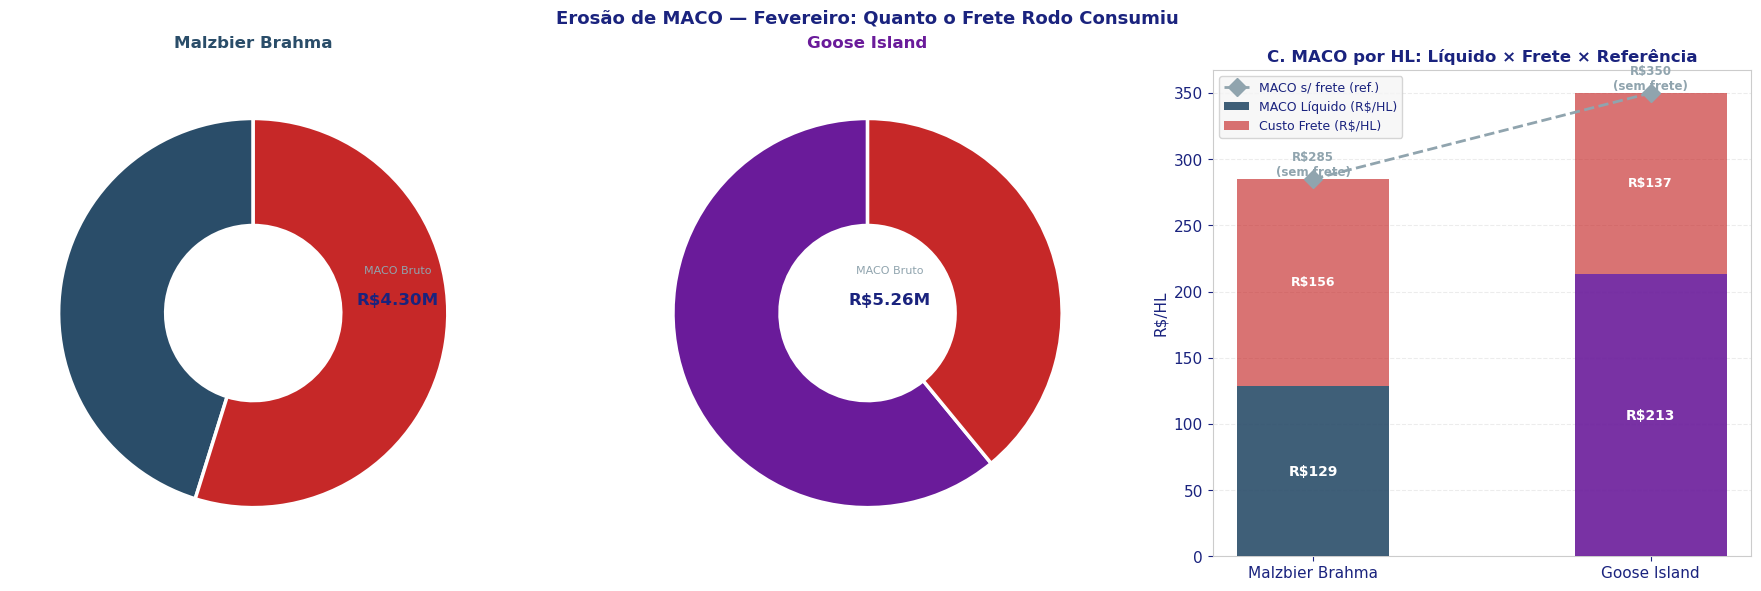

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Erosão de MACO — Fevereiro: Quanto o Frete Rodo Consumiu', fontsize=13,
             fontweight='bold', color=NAVY)

# ── A: Gauge de erosão por SKU (donut) ────────────────────────────────────────
for ax, sku in zip(axes[:2], ['MALZBIER','GOOSE']):
    r = res_fev[sku]
    erosao = r['custo']/r['maco_bruto']*100 if r['maco_bruto']>0 else 0
    liquido= 100 - erosao
    wedges, _ = ax.pie(
        [liquido, erosao],
        colors=[CORES[sku], VERM],
        startangle=90,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5),
    )
    cor_erosao = VERM if erosao>40 else AMARELO
    ax.set_title(LABELS[sku], fontsize=12, fontweight='bold', color=CORES[sku], pad=16)

    bbox = ax.get_position()
    cx = bbox.x0 + bbox.width/2
    cy = bbox.y0 + bbox.height/2
    fig.text(cx, cy+0.05, 'MACO Bruto', ha='center', va='center', fontsize=8, color=CINZA)
    fig.text(cx, cy,      f'R${r["maco_bruto"]/1e6:.2f}M', ha='center', va='center',
             fontsize=12, color=NAVY, fontweight='bold')

    # Labels externos via annotate
    ax.annotate(f'Líquido\n{liquido:.1f}%\nR${r["maco_liq"]/1e6:.2f}M',
                xy=(-0.7, 0.2), fontsize=9, color=CORES[sku], fontweight='bold',
                ha='center')
    ax.annotate(f'Frete\n{erosao:.1f}%\nR${r["custo"]/1e6:.2f}M',
                xy=(0.7, 0.2), fontsize=9, color=VERM, fontweight='bold',
                ha='center')

# ── B: Custo por HL × MACO por HL — barras empilhadas ─────────────────────────
ax3 = axes[2]
skus_t = ['MALZBIER','GOOSE']  # Colorado sem transf em fev
custo_hl_vals  = [res_fev[s]['custo_hl']       for s in skus_t]
maco_liq_hl    = [MACO[s]-res_fev[s]['custo_hl'] for s in skus_t]
maco_local_hl  = [MACO[s]                 for s in skus_t]
x2 = np.arange(2)
bars_liq = ax3.bar(x2, maco_liq_hl,  0.45, color=[CORES[s] for s in skus_t], alpha=0.9,
                   label='MACO Líquido (R$/HL)', zorder=3)
bars_frt = ax3.bar(x2, custo_hl_vals, 0.45, bottom=maco_liq_hl, color=VERM, alpha=0.65,
                   label='Custo Frete (R$/HL)', zorder=3)
ax3.plot(x2, maco_local_hl, 'D--', color=CINZA, lw=2, ms=9,
         label='MACO s/ frete (ref.)', zorder=5)
for i,(liq,frt,loc) in enumerate(zip(maco_liq_hl,custo_hl_vals,maco_local_hl)):
    ax3.text(i, liq/2,   f'R${liq:.0f}', ha='center', va='center',
             fontsize=10, fontweight='bold', color='white')
    ax3.text(i, liq+frt/2, f'R${frt:.0f}', ha='center', va='center',
             fontsize=9, fontweight='bold', color='white')
    ax3.text(i, loc+3, f'R${loc:.0f}\n(sem frete)', ha='center',
             fontsize=8.5, color=CINZA, fontweight='bold')
ax3.set_xticks(x2); ax3.set_xticklabels([LABELS[s] for s in skus_t])
ax3.set_ylabel('R$/HL')
ax3.set_title('C. MACO por HL: Líquido × Frete × Referência')
ax3.legend(fontsize=9); ax3.grid(axis='y', zorder=0)

plt.tight_layout()
plt.savefig('g_mar_3_erosao_fev.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()


## 6. Gráfico 4 — Erosão de MACO Março Isolada


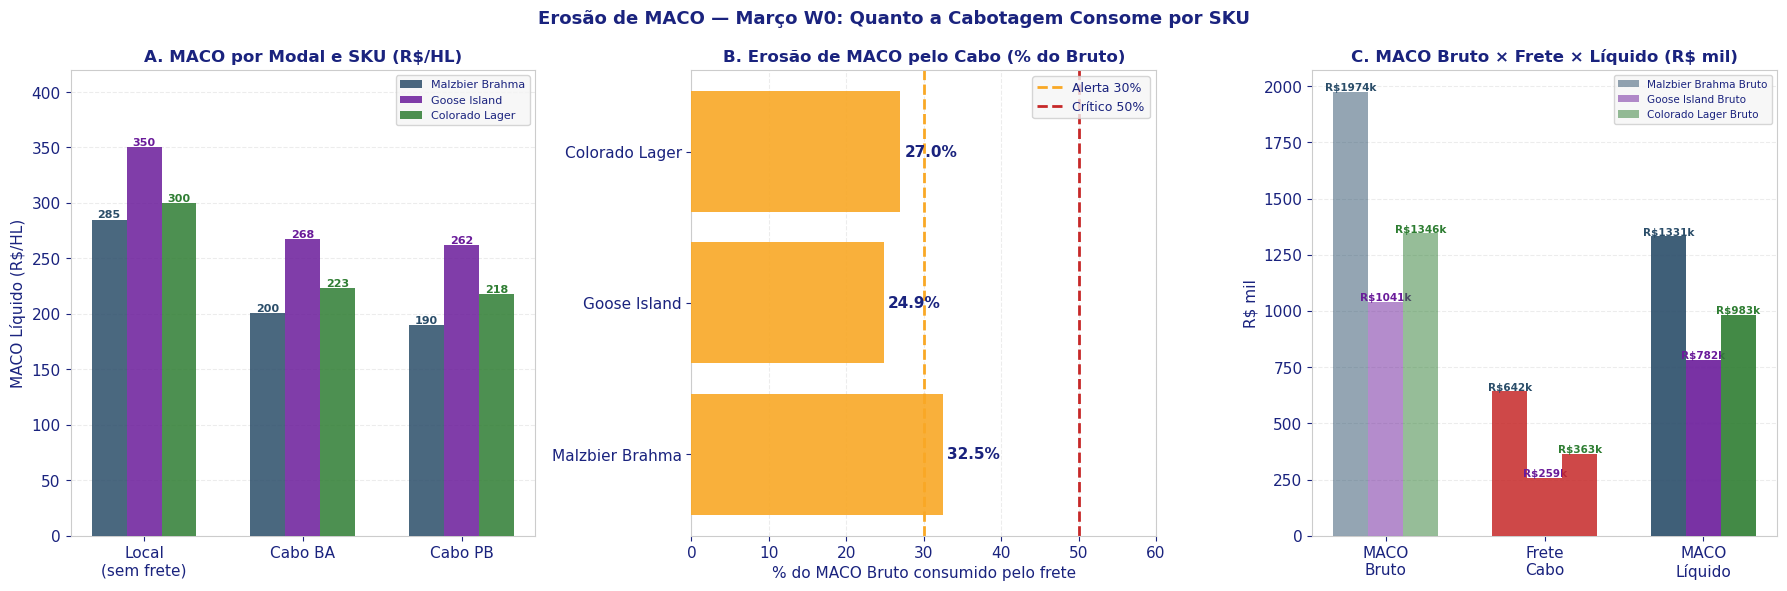

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Erosão de MACO — Março W0: Quanto a Cabotagem Consome por SKU', fontsize=13,
             fontweight='bold', color=NAVY)

# ── A: MACO por modal cabo por SKU ────────────────────────────────────────────
ax = axes[0]
modais_m = ['Local\n(sem frete)', 'Cabo BA', 'Cabo PB']
x3 = np.arange(3); w3 = 0.22
for i, sku in enumerate(SKUS):
    vals = [MACO[sku],
            MACO[sku] - _CABO[(sku,'BA')],
            MACO[sku] - _CABO[(sku,'PB')]]
    offset = (i-1) * w3
    bars = ax.bar(x3 + offset, vals, w3, color=CORES[sku], alpha=0.85,
                  label=LABELS[sku], zorder=3)
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.0f}',
                ha='center', fontsize=8, fontweight='bold', color=CORES[sku])
ax.set_xticks(x3); ax.set_xticklabels(modais_m)
ax.set_ylabel('MACO Líquido (R$/HL)')
ax.set_title('A. MACO por Modal e SKU (R$/HL)')
ax.legend(fontsize=8); ax.grid(axis='y', zorder=0)
ax.set_ylim(0, max(MACO.values())*1.2)

# ── B: Erosão % por SKU — barras horizontais ──────────────────────────────────
ax2 = axes[1]
erosao_mar = [res_mar[s]['erosao_pct'] for s in SKUS]
cores_er   = [VERM if e>35 else AMARELO if e>20 else VERDE for e in erosao_mar]
bars = ax2.barh([LABELS[s] for s in SKUS], erosao_mar,
                color=cores_er, alpha=0.9, zorder=3)
ax2.axvline(30, color=AMARELO, lw=2, ls='--', label='Alerta 30%')
ax2.axvline(50, color=VERM,    lw=2, ls='--', label='Crítico 50%')
for b,v in zip(bars, erosao_mar):
    ax2.text(v+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}%',
             va='center', fontsize=11, fontweight='bold', color=NAVY)
ax2.set_xlabel('% do MACO Bruto consumido pelo frete')
ax2.set_title('B. Erosão de MACO pelo Cabo (% do Bruto)')
ax2.legend(fontsize=9); ax2.grid(axis='x', zorder=0)
ax2.set_xlim(0, 60)

# ── C: Waterfall por SKU lado a lado ─────────────────────────────────────────
ax3 = axes[2]
x3  = np.arange(3); w3 = 0.22
for i, sku in enumerate(SKUS):
    r    = res_mar[sku]
    bruto = r['maco_bruto']/1e3
    frete = r['custo']/1e3
    liq   = r['maco_liq']/1e3
    offset = (i-1)*w3
    ax3.bar(0+offset, bruto, w3, color=CORES[sku], alpha=0.5,
            label=f'{LABELS[sku]} Bruto', zorder=3)
    ax3.bar(1+offset, frete, w3, color=VERM,        alpha=0.85, zorder=3)
    ax3.bar(2+offset, liq,   w3, color=CORES[sku], alpha=0.9,  zorder=3)
    # Rótulos
    for xi,v in zip([0,1,2],[bruto,frete,liq]):
        ax3.text(xi+offset, v+5, f'R${v:.0f}k', ha='center',
                 fontsize=7.5, fontweight='bold', color=CORES[sku])
cats3 = ['MACO\nBruto', 'Frete\nCabo', 'MACO\nLíquido']
ax3.set_xticks([0,1,2]); ax3.set_xticklabels(cats3)
ax3.set_ylabel('R$ mil')
ax3.set_title('C. MACO Bruto × Frete × Líquido (R$ mil)')
ax3.legend(fontsize=7.5, ncol=1); ax3.grid(axis='y', zorder=0)

plt.tight_layout()
plt.savefig('g_mar_4_erosao_mar.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()


## 7. Gráfico 5 — DOI Março W0: Antes e Depois da Cabotagem


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('DOI Março W0 — Sem vs Com Cabotagem', fontsize=13,
             fontweight='bold', color=NAVY)

x = np.arange(3); w = 0.35
doi_sem_mar = [res_mar[s]['doi_sem'] for s in SKUS]
doi_fin_mar = [res_mar[s]['doi_fin'] for s in SKUS]

# ── A: Barras antes/depois ────────────────────────────────────────────────────
ax = axes[0]
b1 = ax.bar(x - w/2, doi_sem_mar, w, color=VERM,   alpha=0.85, label='s/ cabotagem', zorder=3)
b2 = ax.bar(x + w/2, doi_fin_mar, w, color=CABO_C, alpha=0.85, label='c/ cabotagem', zorder=3)
ax.axhline(DOI_MIN, color=AMARELO, lw=2.5, ls='--', label=f'DOI mín {DOI_MIN}d')
for i,(ds,df) in enumerate(zip(doi_sem_mar, doi_fin_mar)):
    ax.text(i-w/2, ds+0.3, f'{ds:.1f}d', ha='center', fontsize=10, fontweight='bold',
            color=VERDE if ds>=DOI_MIN else VERM)
    ax.text(i+w/2, df+0.3, f'{df:.1f}d', ha='center', fontsize=10, fontweight='bold', color=CABO_C)
ax.set_xticks(x); ax.set_xticklabels([LABELS[s] for s in SKUS])
ax.set_ylabel('DOI (dias)'); ax.set_title('A. DOI Março W0: Antes e Depois')
ax.legend(fontsize=9); ax.grid(axis='y', zorder=0)

# ── B: Volume de cabotagem necessário por SKU ─────────────────────────────────
ax2 = axes[1]
transf_mar = [res_mar[s]['transf'] for s in SKUS]
CORES['MALZBIER'] = '#2a4d69'   # azul escuro
CORES['GOOSE']    = '#00838f'   # verde-azulado
CORES['COLORADO'] = "#5792ff"
#cores_t = [CORES[s] for s in SKUS]
bars = ax2.bar([LABELS[s] for s in SKUS], transf_mar, color=cores_t, alpha=0.9, zorder=3, width=0.45)
for b,v in zip(bars, transf_mar):
    ax2.text(b.get_x()+b.get_width()/2, v+80, f'{v:,.0f} HL',
             ha='center', fontsize=10, fontweight='bold', color=NAVY)
    pct = v/res_mar[SKUS[list(bars).index(b)]]["dem"]*100 if False else 0
ax2.set_ylabel('HL'); ax2.set_title('B. Volume Cabotagem Necessário por SKU (W0)')
ax2.grid(axis='y', zorder=0)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:,.0f}'))

plt.tight_layout()
plt.savefig('g_mar_5_doi_mar.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()


NameError: name 'plt' is not defined

## 8. Gráfico 6 — Painel de Erosão de MACO — Março


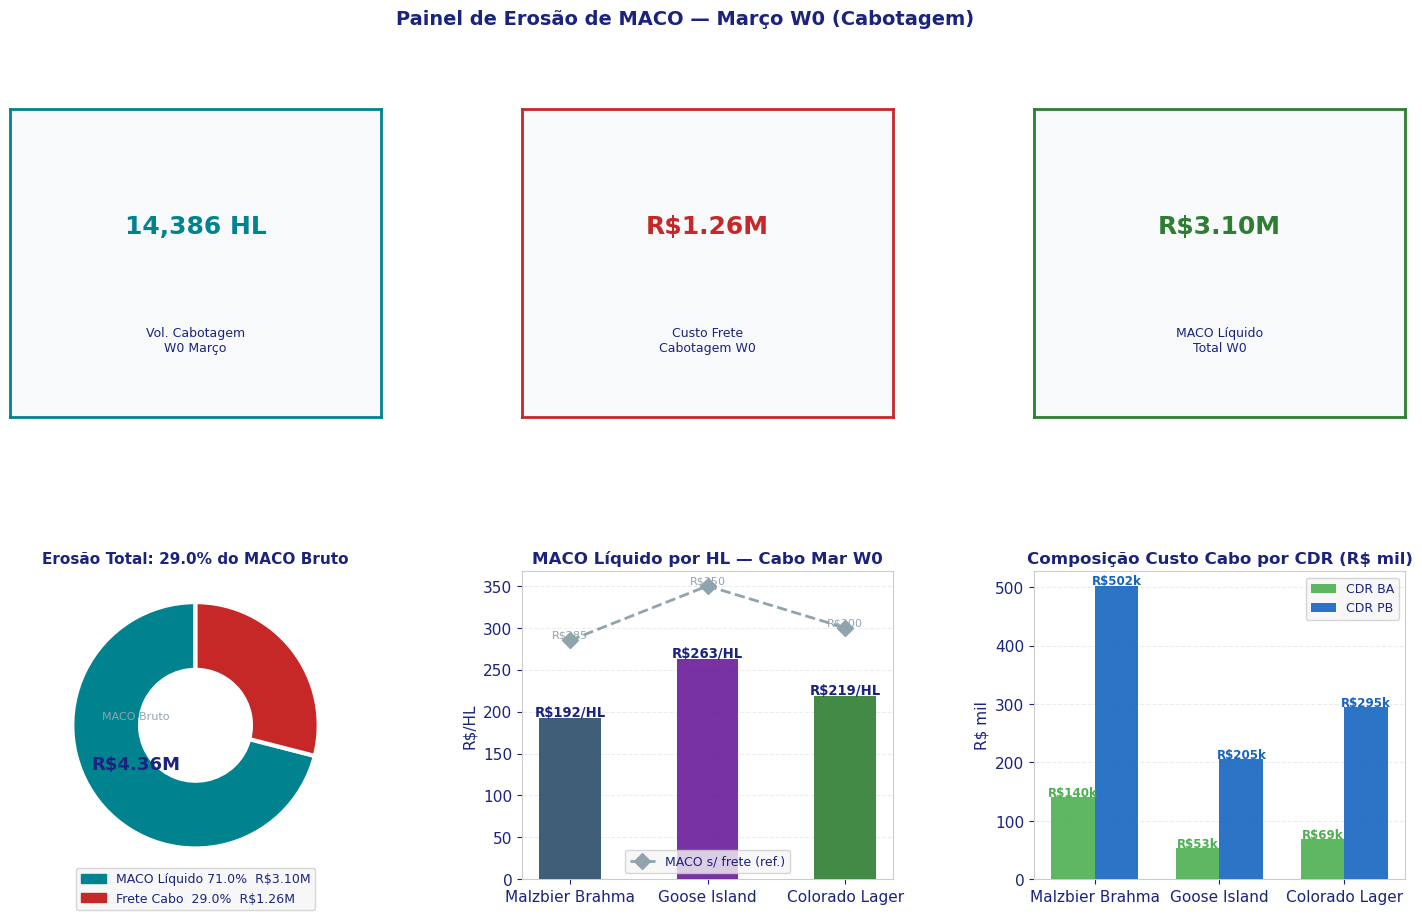

In [ ]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)
fig.patch.set_facecolor('#ffffff')
fig.suptitle('Painel de Erosão de MACO — Março W0 (Cabotagem)', fontsize=14,
             fontweight='bold', color=NAVY)

# ── KPIs ─────────────────────────────────────────────────────────────────────
tot_transf  = sum(res_mar[s]['transf']     for s in SKUS)
tot_custo   = sum(res_mar[s]['custo']      for s in SKUS)
tot_bruto   = sum(res_mar[s]['maco_bruto'] for s in SKUS)
tot_liq     = sum(res_mar[s]['maco_liq']   for s in SKUS)
erosao_tot  = tot_custo/tot_bruto*100 if tot_bruto>0 else 0

kpis = [
    ('Vol. Cabotagem\nW0 Março',  f'{tot_transf:,.0f} HL',           CABO_C),
    ('Custo Frete\nCabotagem W0', f'R${tot_custo/1e6:.2f}M',         VERM),
    ('MACO Líquido\nTotal W0',    f'R${tot_liq/1e6:.2f}M',           VERDE),
]
for i,(lbl,val,cor) in enumerate(kpis):
    ax_k = fig.add_subplot(gs[0, i])
    ax_k.set_facecolor('#f8f9fa')
    ax_k.text(0.5, 0.62, val, ha='center', va='center', fontsize=18,
              fontweight='bold', color=cor, transform=ax_k.transAxes)
    ax_k.text(0.5, 0.25, lbl, ha='center', va='center', fontsize=9,
              color=NAVY, transform=ax_k.transAxes)
    for spine in ax_k.spines.values():
        spine.set_edgecolor(cor); spine.set_linewidth(2)
    ax_k.set_xticks([]); ax_k.set_yticks([])

# ── Donut erosão consolidada ──────────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 0])
liq_pct  = tot_liq/tot_bruto*100
wedges,_ = ax_d.pie(
    [liq_pct, erosao_tot],
    colors=[CABO_C, VERM],
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
)
fig.text(0.195, 0.27, 'MACO Bruto', ha='center', fontsize=8, color=CINZA)
fig.text(0.195, 0.22, f'R${tot_bruto/1e6:.2f}M', ha='center', fontsize=13,
         color=NAVY, fontweight='bold')
ax_d.set_title(f'Erosão Total: {erosao_tot:.1f}% do MACO Bruto',
               fontsize=11, fontweight='bold', color=NAVY)

import matplotlib.patches as mpatches
leg_d = [mpatches.Patch(color=CABO_C, label=f'MACO Líquido {liq_pct:.1f}%  R${tot_liq/1e6:.2f}M'),
         mpatches.Patch(color=VERM,   label=f'Frete Cabo  {erosao_tot:.1f}%  R${tot_custo/1e6:.2f}M')]
ax_d.legend(handles=leg_d, loc='lower center', bbox_to_anchor=(0.5,-0.12), fontsize=9)

# ── MACO líquido por HL por SKU ───────────────────────────────────────────────
ax_hl = fig.add_subplot(gs[1, 1])
maco_liq_hl = [res_mar[s]['maco_liq_hl'] for s in SKUS]
maco_ref    = [MACO[s]               for s in SKUS]
bars_hl = ax_hl.bar([LABELS[s] for s in SKUS], maco_liq_hl,
                    color=[CORES[s] for s in SKUS], alpha=0.9, zorder=3, width=0.45)
ax_hl.plot(range(3), maco_ref, 'D--', color=CINZA, lw=2, ms=8, label='MACO s/ frete (ref.)', zorder=5)
for b,v,ref in zip(bars_hl, maco_liq_hl, maco_ref):
    ax_hl.text(b.get_x()+b.get_width()/2, v+2, f'R${v:.0f}/HL',
               ha='center', fontsize=9.5, fontweight='bold', color=NAVY)
    ax_hl.text(b.get_x()+b.get_width()/2, ref+3, f'R${ref:.0f}',
               ha='center', fontsize=8, color=CINZA)
ax_hl.set_ylabel('R$/HL')
ax_hl.set_title('MACO Líquido por HL — Cabo Mar W0')
ax_hl.legend(fontsize=9); ax_hl.grid(axis='y', zorder=0)

# ── Composição custo cabo por SKU (BA vs PB) ──────────────────────────────────
ax_cdr = fig.add_subplot(gs[1, 2])
ba_vals_m = [res_mar[s]['custo_ba']/1e3 for s in SKUS]
pb_vals_m = [res_mar[s]['custo_pb']/1e3 for s in SKUS]
x3 = np.arange(3); w3 = 0.35
ax_cdr.bar(x3-w3/2, ba_vals_m, w3, color='#4caf50', alpha=0.9, label='CDR BA', zorder=3)
ax_cdr.bar(x3+w3/2, pb_vals_m, w3, color='#1565c0', alpha=0.9, label='CDR PB', zorder=3)
for i,(ba,pb) in enumerate(zip(ba_vals_m, pb_vals_m)):
    if ba>0: ax_cdr.text(i-w3/2, ba+2, f'R${ba:.0f}k', ha='center', fontsize=8.5, fontweight='bold', color='#4caf50')
    if pb>0: ax_cdr.text(i+w3/2, pb+2, f'R${pb:.0f}k', ha='center', fontsize=8.5, fontweight='bold', color='#1565c0')
ax_cdr.set_xticks(x3); ax_cdr.set_xticklabels([LABELS[s] for s in SKUS])
ax_cdr.set_ylabel('R$ mil')
ax_cdr.set_title('Composição Custo Cabo por CDR (R$ mil)')
ax_cdr.legend(fontsize=9); ax_cdr.grid(axis='y', zorder=0)

plt.savefig('g_mar_6_painel_erosao.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()
